# Workflow
1. Getting customer data
2. Data pre-processing
3. Data Analysis
4. Optimum number of Clusters
5. Feeding the data into a K-Means Clustering
6. Visualizing the Clusters

In [18]:
# importing the dependancies
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
# loadin the dataset
mall = pd.read_csv('Mall_Customers.csv')

In [4]:
mall.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
mall.shape

(200, 5)

In [6]:
# getting info about dataset
mall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
# cheking for missing values
mall.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [13]:
mall['Gender'] = mall['Gender'].map({'Male':1, 'Female':0})
X = mall.iloc[:,[1,2,3,4]].values

In [14]:
print(X)

[[  1  19  15  39]
 [  1  21  15  81]
 [  0  20  16   6]
 [  0  23  16  77]
 [  0  31  17  40]
 [  0  22  17  76]
 [  0  35  18   6]
 [  0  23  18  94]
 [  1  64  19   3]
 [  0  30  19  72]
 [  1  67  19  14]
 [  0  35  19  99]
 [  0  58  20  15]
 [  0  24  20  77]
 [  1  37  20  13]
 [  1  22  20  79]
 [  0  35  21  35]
 [  1  20  21  66]
 [  1  52  23  29]
 [  0  35  23  98]
 [  1  35  24  35]
 [  1  25  24  73]
 [  0  46  25   5]
 [  1  31  25  73]
 [  0  54  28  14]
 [  1  29  28  82]
 [  0  45  28  32]
 [  1  35  28  61]
 [  0  40  29  31]
 [  0  23  29  87]
 [  1  60  30   4]
 [  0  21  30  73]
 [  1  53  33   4]
 [  1  18  33  92]
 [  0  49  33  14]
 [  0  21  33  81]
 [  0  42  34  17]
 [  0  30  34  73]
 [  0  36  37  26]
 [  0  20  37  75]
 [  0  65  38  35]
 [  1  24  38  92]
 [  1  48  39  36]
 [  0  31  39  61]
 [  0  49  39  28]
 [  0  24  39  65]
 [  0  50  40  55]
 [  0  27  40  47]
 [  0  29  40  42]
 [  0  31  40  42]
 [  0  49  42  52]
 [  1  33  42  60]
 [  0  31  4

In [15]:
# finding WCSS value for different no of clusters
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    
    wcss.append(kmeans.inertia_)

C:\Users\osumb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\osumb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\osumb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\osumb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

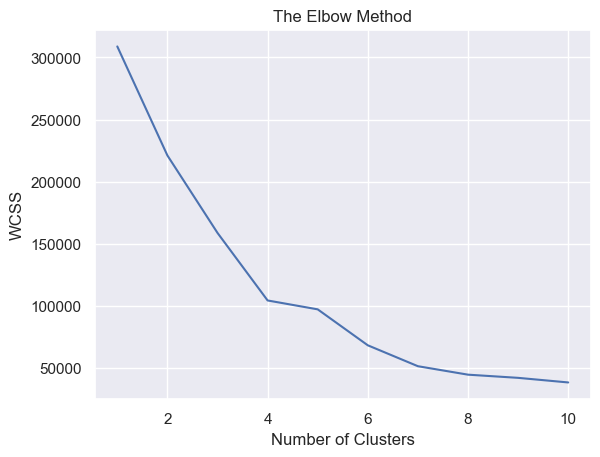

In [19]:
# plot an elbow graph
sns.set()
plt.plot(range(1,11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [24]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
Y = kmeans.fit_predict(X) #vreturns a label for each data point
print(Y)

[2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 2 0 0 0 2 0 0 2 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0
 4 0 0 0 4 0 0 0 0 4 0 4 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


C:\Users\osumb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


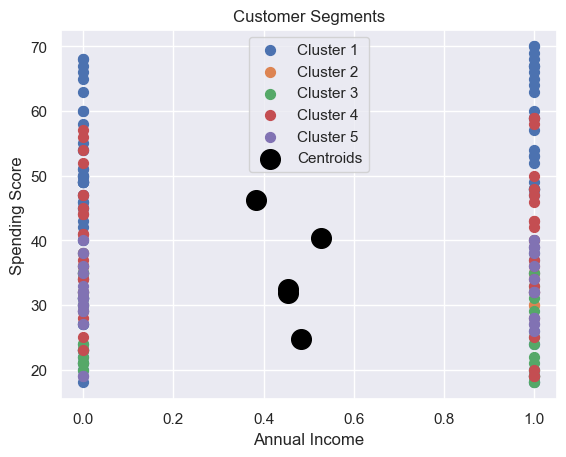

In [23]:
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, label='Cluster 1')
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, label='Cluster 2')
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, label='Cluster 3')
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, label='Cluster 4')
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            s=200, c='black', label='Centroids')

plt.title('Customer Segments')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

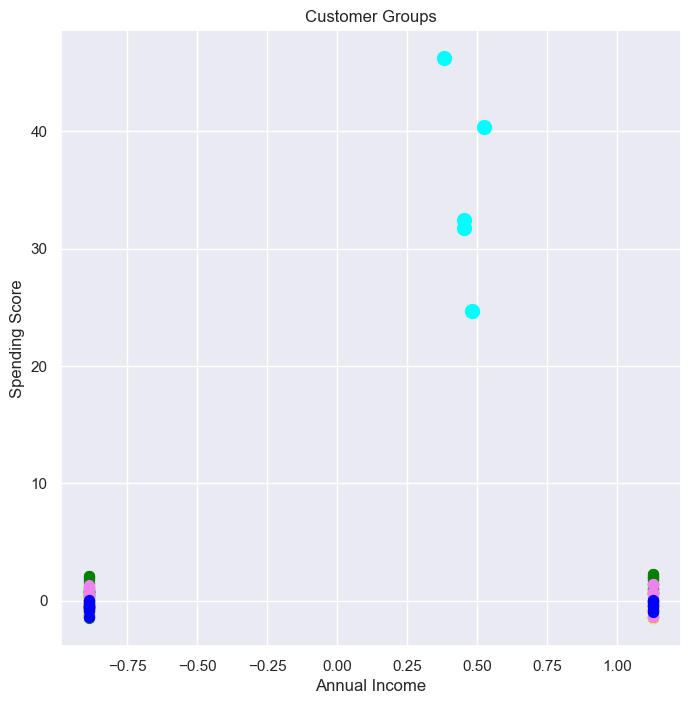

In [26]:
# plotting all the clusters and their Centroids

plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label='Cluster 1')
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='red', label='Cluster 2')
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='yellow', label='Cluster 3')
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='violet', label='Cluster 4')
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='blue', label='Cluster 5')

# plot the centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='cyan', label='Centroids')

plt.title('Customer Groups')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()